Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


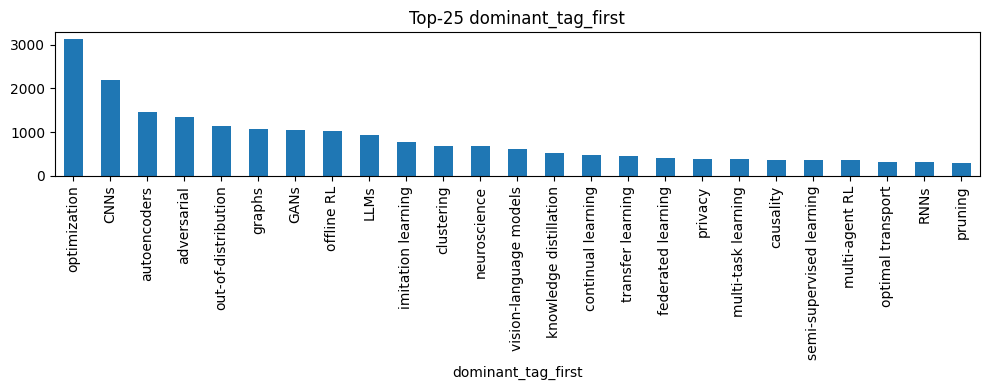

Privacy papers: 393
[Privacy graph] nodes: 1087 edges: 3876
Centrality compute modes: {'betweenness': 'exact', 'closeness': 'exact', 'eigenvector': 'exact_power'}
Modularity: 0.893899 | communities: 137


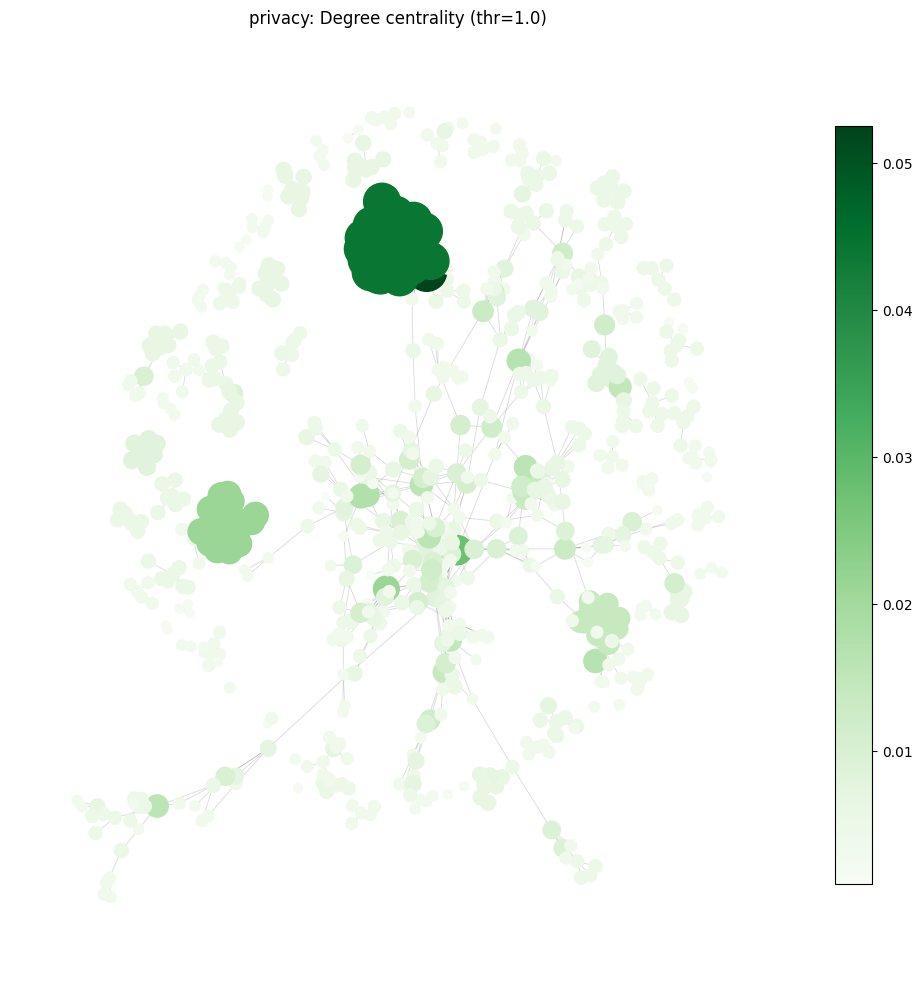

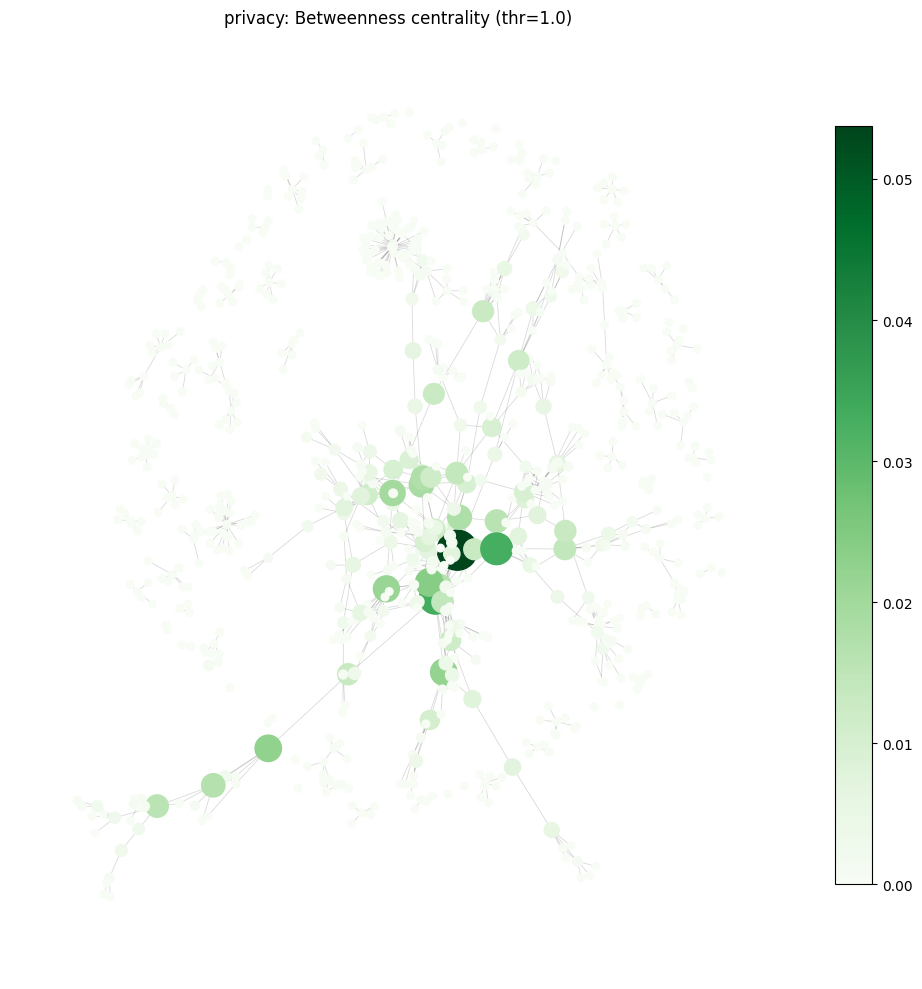

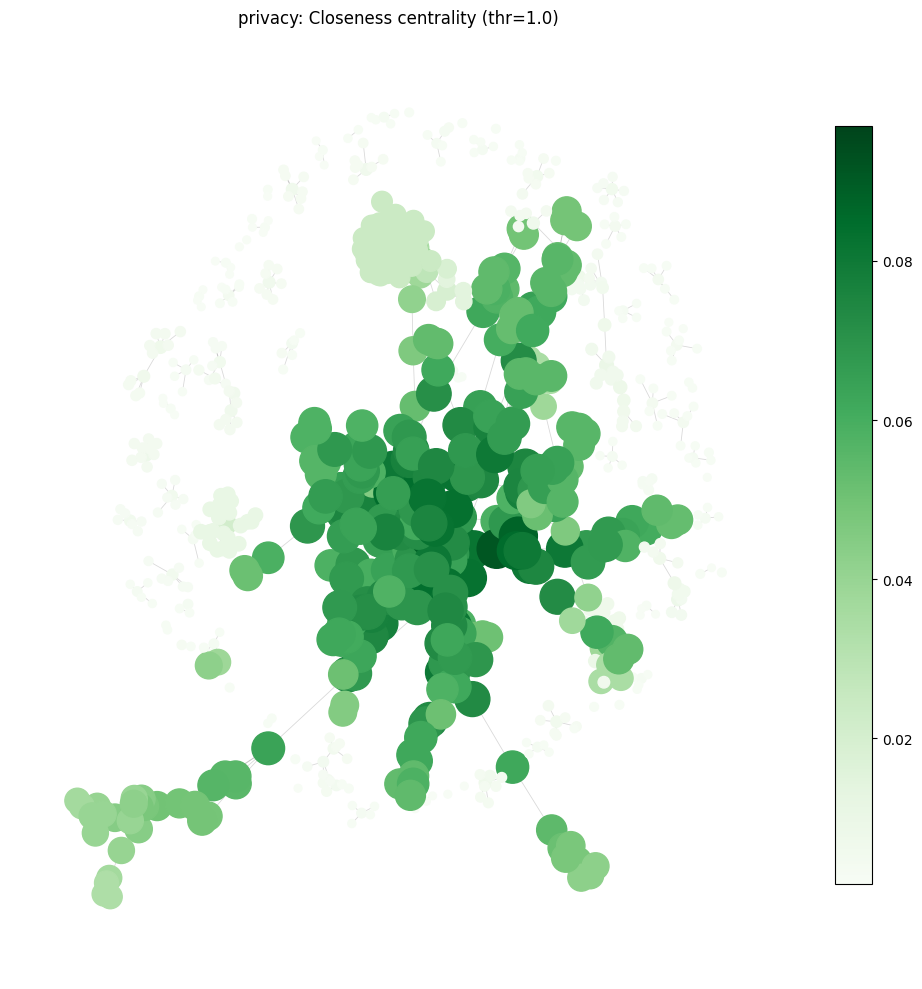

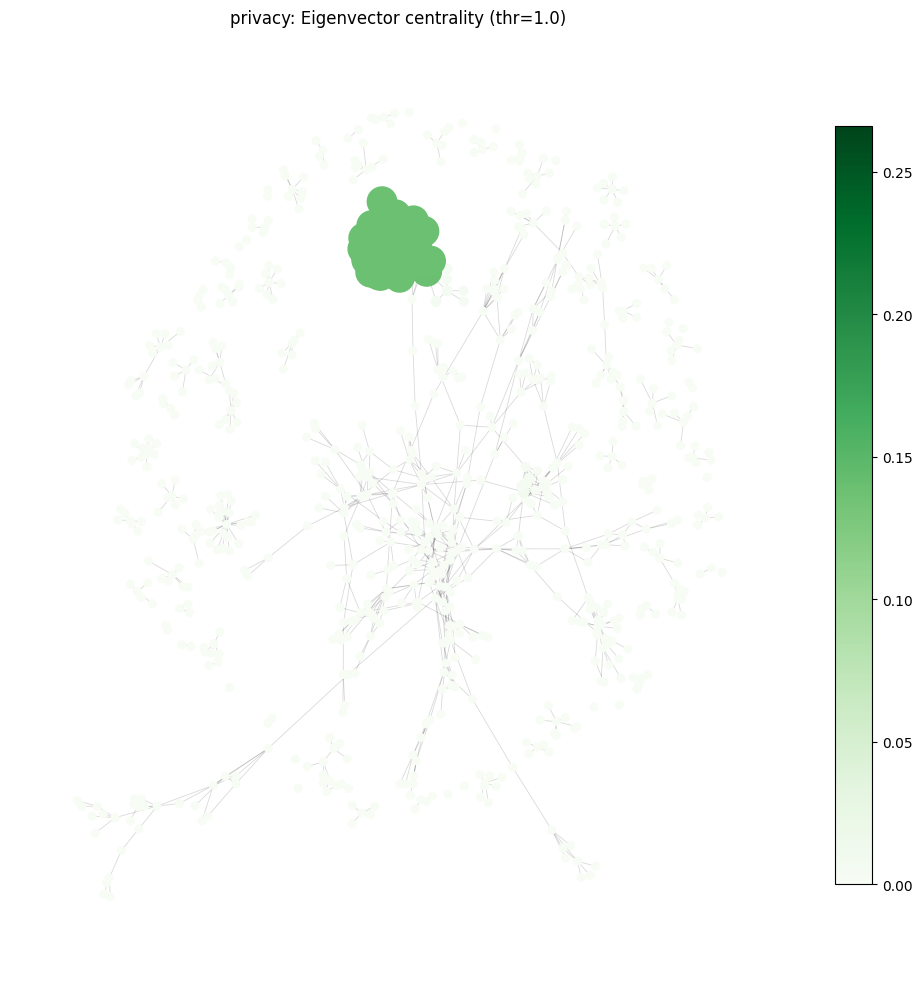

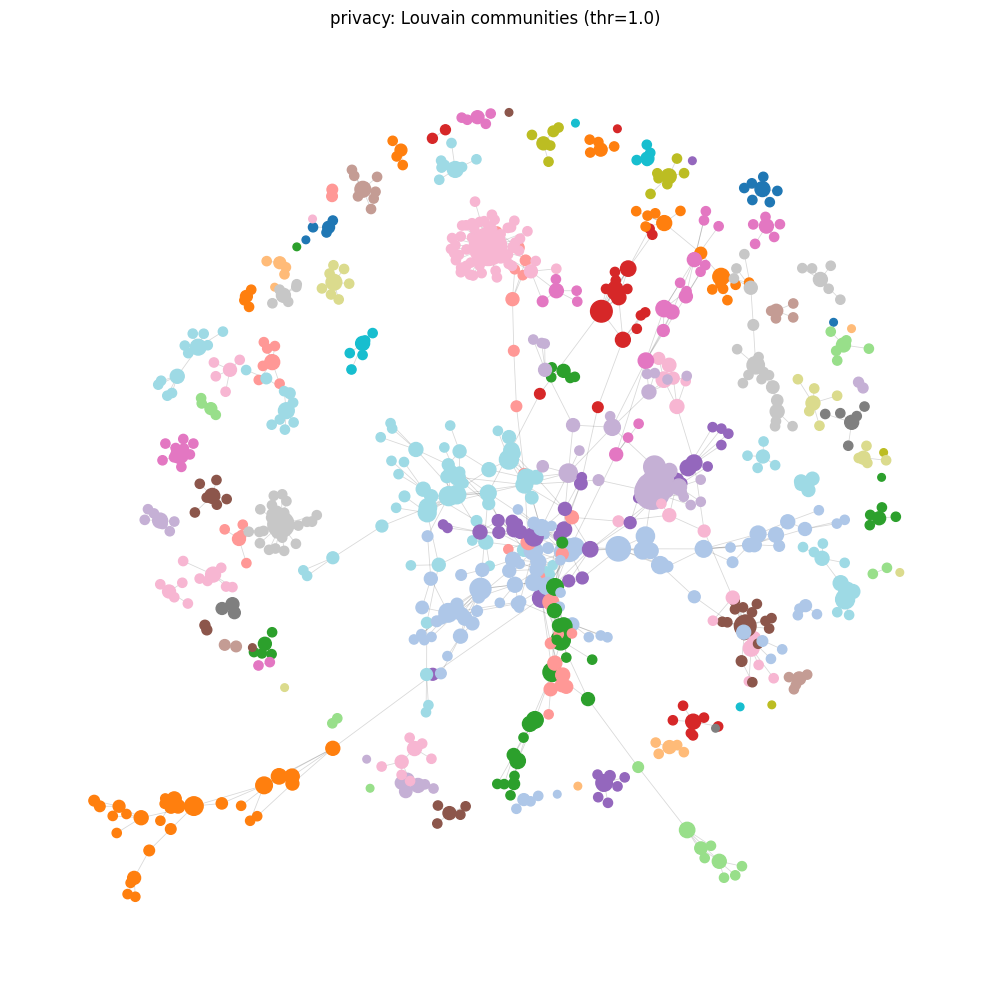

Done. Artifacts saved to: /content/drive/MyDrive/collab_results_bananika/privacy_20260202_214817
Total pipeline time: 17.18 s
Saved privacy_papers.csv


In [ ]:
!pip -q install python-louvain

from google.colab import drive
drive.mount('/content/drive')

import os, time, json, pickle
import pandas as pd
import numpy as np
import ast
import networkx as nx
from itertools import combinations
from collections import Counter
import matplotlib.pyplot as plt

FILE_PATH   = "/content/drive/MyDrive/bananika.csv"
OUTPUT_BASE = "/content/drive/MyDrive/collab_results_bananika"
PRIVACY_TAG = "privacy"

BETWEENNESS_EXACT_MAX = 1500
BETWEENNESS_K         = 800

CLOSENESS_EXACT_MAX   = 2000
CLOSENESS_TOPK        = 300

EIGENVECTOR_EXACT_MAX = 4000

TOP_NODES_FOR_DRAW    = 800
EDGE_THRESH_USER      = None
RANDOM_SEED           = 0

def save_gpickle(G, path):
    with open(path, "wb") as f:
        pickle.dump(G, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_gpickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

df = pd.read_csv(FILE_PATH)
df = df.loc[:, ~df.columns.str.match(r"^Unnamed")].copy()

def _to_list(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if (s.startswith("[") and s.endswith("]")) or (s.startswith("(") and s.endswith(")")):
            try:
                v = ast.literal_eval(s)
                return v if isinstance(v, list) else []
            except Exception:
                return []
        return [s]
    return []

def dominant_first_tag(row):
    tags = _to_list(row.get("tags_semantic", None))
    if len(tags) > 0 and isinstance(tags[0], str) and tags[0].strip():
        return tags[0].strip()
    dt = row.get("dominant_tag", None)
    if isinstance(dt, str) and dt.strip():
        return dt.strip()
    return None

df["dominant_tag_first"] = df.apply(dominant_first_tag, axis=1)
df["dominant_tag_first_norm"] = df["dominant_tag_first"].astype(str).str.strip().str.lower()

os.makedirs(OUTPUT_BASE, exist_ok=True)
tag_counts = df["dominant_tag_first"].value_counts(dropna=True)
tag_counts.to_csv(os.path.join(OUTPUT_BASE, "dominant_tag_first_counts.csv"), header=["count"])
plt.figure(figsize=(10,4))
tag_counts.head(25).plot(kind="bar")
plt.title("Top-25 dominant_tag_first")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_BASE, "dominant_tag_first_top25.png"), dpi=200)
plt.show()

privacy_df = df[df["dominant_tag_first_norm"] == PRIVACY_TAG.lower()].copy()
print("Privacy papers:", len(privacy_df))

SUFFIXES = {"jr.", "sr.", "ii", "iii", "iv"}

def parse_authors(cell):
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return []
    if isinstance(cell, list):
        return [str(a).strip() for a in cell if str(a).strip()]

    s = str(cell).strip()
    if not s:
        return []

    if s.startswith("[") and s.endswith("]"):
        try:
            v = ast.literal_eval(s)
            if isinstance(v, list):
                return [str(a).strip() for a in v if str(a).strip()]
        except Exception:
            pass

    s = s.replace(" and ", ", ").replace(";", ",")
    parts = [p.strip() for p in s.split(",") if p.strip()]

    out = []
    for p in parts:
        if out and p.lower() in SUFFIXES:
            out[-1] = out[-1] + ", " + p
        else:
            out.append(p)

    seen = set()
    uniq = []
    for a in out:
        if a not in seen:
            seen.add(a)
            uniq.append(a)
    return uniq

def build_weighted_graph_paperstyle(frame, authors_col="authors", max_rows=None):
    edge_w = Counter()
    total_papers = Counter()
    lead_papers = Counter()

    it = frame.head(max_rows) if max_rows else frame

    for _, row in it.iterrows():
        authors = parse_authors(row.get(authors_col, None))
        authors = [a for a in authors if a]
        if len(authors) == 0:
            continue

        # unique per paper (preserve first-author)
        seen = set()
        uniq = []
        for a in authors:
            if a not in seen:
                seen.add(a)
                uniq.append(a)
        authors = uniq

        lead = authors[0]
        total_papers[lead] += 1
        lead_papers[lead] += 1
        for a in authors[1:]:
            total_papers[a] += 1

        # lead-member edges: +1
        for a in authors[1:]:
            u, v = (lead, a) if lead < a else (a, lead)
            edge_w[(u, v)] += 1.0

        # member-member edges: +0.5
        members = authors[1:]
        for u, v in combinations(members, 2):
            u, v = (u, v) if u < v else (v, u)
            edge_w[(u, v)] += 0.5

    G = nx.Graph()
    for a, cnt in total_papers.items():
        G.add_node(a, papers=int(cnt), lead_papers=int(lead_papers.get(a, 0)))
    for (u, v), w in edge_w.items():
        G.add_edge(u, v, weight=float(w))
    return G

# --------------------- ANALYSIS HELPERS ---------------------
def ensure_distance_attr(G):
    for _, _, d in G.edges(data=True):
        w = d.get("weight", 1.0)
        d["distance"] = 1.0 / max(w, 1e-12)

def louvain_partition(G):
    try:
        from networkx.algorithms.community import louvain_communities
        comms = louvain_communities(G, weight="weight", seed=RANDOM_SEED)
        part = {}
        for i, c in enumerate(comms):
            for n in c:
                part[n] = i
        return part, comms
    except Exception:
        import community as community_louvain
        part = community_louvain.best_partition(G, weight="weight", random_state=RANDOM_SEED)
        comm_map = {}
        for n, cid in part.items():
            comm_map.setdefault(cid, []).append(n)
        comms = [set(v) for _, v in sorted(comm_map.items(), key=lambda x: x[0])]
        return part, comms

def pick_edge_threshold(G):
    ws = [d.get("weight", 1.0) for _, _, d in G.edges(data=True)]
    if len(ws) == 0:
        return 0.0
    if EDGE_THRESH_USER is not None:
        return float(EDGE_THRESH_USER)
    q = float(np.quantile(ws, 0.90))
    return max(1.0, round(q, 2))

def threshold_graph(G, thr):
    if thr <= 0:
        return G.copy()
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    for u, v, d in G.edges(data=True):
        if d.get("weight", 0.0) >= thr:
            H.add_edge(u, v, **d)
    H.remove_nodes_from([n for n in H.nodes() if H.degree(n) == 0])
    return H

def compute_centralities(G):
    ensure_distance_attr(G)
    n = G.number_of_nodes()

    deg_cent = nx.degree_centrality(G)

    strength = dict(G.degree(weight="weight"))
    max_strength = max(strength.values()) if strength else 1.0
    strength_norm = {k: (v / max_strength) for k, v in strength.items()}

    if n <= BETWEENNESS_EXACT_MAX:
        btw = nx.betweenness_centrality(G, weight="distance", normalized=True)
        btw_mode = "exact"
    else:
        k = min(BETWEENNESS_K, n)
        btw = nx.betweenness_centrality(G, k=k, weight="distance", normalized=True, seed=RANDOM_SEED)
        btw_mode = f"approx_k={k}"

    if n <= CLOSENESS_EXACT_MAX:
        clo = nx.closeness_centrality(G, distance="distance")
        clo_mode = "exact"
    else:
        top_nodes = sorted(strength.items(), key=lambda x: x[1], reverse=True)[:min(CLOSENESS_TOPK, n)]
        clo = {node: nx.closeness_centrality(G, u=node, distance="distance") for node, _ in top_nodes}
        clo_mode = f"topk={len(top_nodes)}"

    if n <= EIGENVECTOR_EXACT_MAX:
        try:
            eig = nx.eigenvector_centrality(G, weight="weight", max_iter=2000, tol=1e-6)
            eig_mode = "exact_power"
        except Exception:
            eig = nx.pagerank(G, weight="weight")
            eig_mode = "fallback_pagerank"
    else:
        eig = nx.pagerank(G, weight="weight")
        eig_mode = "pagerank_proxy"

    return {
        "degree_centrality": deg_cent,
        "weighted_degree_norm": strength_norm,
        "betweenness": btw,
        "closeness": clo,
        "eigenvector": eig,
        "_modes": {"betweenness": btw_mode, "closeness": clo_mode, "eigenvector": eig_mode},
    }

def save_rank_tables(G, cent, out_dir, prefix):
    nodes = list(G.nodes())
    papers = nx.get_node_attributes(G, "papers")
    lead_papers = nx.get_node_attributes(G, "lead_papers")

    dfc = pd.DataFrame({
        "author": nodes,
        "papers": [papers.get(n, 0) for n in nodes],
        "lead_papers": [lead_papers.get(n, 0) for n in nodes],
        "degree_centrality": [cent["degree_centrality"].get(n, np.nan) for n in nodes],
        "weighted_degree_norm": [cent["weighted_degree_norm"].get(n, np.nan) for n in nodes],
        "betweenness": [cent["betweenness"].get(n, np.nan) for n in nodes],
        "closeness": [cent["closeness"].get(n, np.nan) for n in nodes],
        "eigenvector": [cent["eigenvector"].get(n, np.nan) for n in nodes],
    })
    dfc.to_csv(os.path.join(out_dir, f"{prefix}_centralities_all.csv"), index=False)

    def top_k(col, k=8):
        tmp = dfc[["author", col]].dropna().sort_values(col, ascending=False).head(k)
        tmp = tmp.rename(columns={col: "value"})
        tmp["metric"] = col
        return tmp[["metric", "author", "value"]]

    summary = pd.concat([
        top_k("degree_centrality"),
        top_k("betweenness"),
        top_k("closeness"),
        top_k("eigenvector"),
        top_k("papers"),
        top_k("lead_papers"),
    ], ignore_index=True)

    summary.to_csv(os.path.join(out_dir, f"{prefix}_top8_summary.csv"), index=False)
    return dfc, summary

def draw_metric_graph(H, metric_values, out_path, title):
    if H.number_of_nodes() == 0 or H.number_of_edges() == 0:
        return
    pos = nx.spring_layout(H, seed=RANDOM_SEED)
    vals = np.array([metric_values.get(n, 0.0) for n in H.nodes()])
    sizes = 30 + 800 * (vals - vals.min()) / (np.ptp(vals) + 1e-12)

    plt.figure(figsize=(10, 10))
    nx.draw_networkx_edges(H, pos, alpha=0.15, width=0.6)
    sc = nx.draw_networkx_nodes(H, pos, node_size=sizes, node_color=vals, cmap="Greens")
    plt.colorbar(sc, shrink=0.8)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(out_path, dpi=250)
    plt.show()

def draw_community_graph(H, part, out_path, title):
    if H.number_of_nodes() == 0 or H.number_of_edges() == 0:
        return
    pos = nx.spring_layout(H, seed=RANDOM_SEED)
    comm_ids = np.array([part.get(n, -1) for n in H.nodes()])

    strength = dict(H.degree(weight="weight"))
    vals = np.array([strength.get(n, 0.0) for n in H.nodes()])
    sizes = 30 + 700 * (vals - vals.min()) / (np.ptp(vals) + 1e-12)

    plt.figure(figsize=(10, 10))
    nx.draw_networkx_edges(H, pos, alpha=0.15, width=0.6)
    nx.draw_networkx_nodes(H, pos, node_size=sizes, node_color=comm_ids, cmap="tab20")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(out_path, dpi=250)
    plt.show()

def run_full_pipeline(G, out_dir, label):
    os.makedirs(out_dir, exist_ok=True)

    save_gpickle(G, os.path.join(out_dir, f"{label}_graph.gpickle"))
    try:
        nx.write_graphml(G, os.path.join(out_dir, f"{label}_graph.graphml"))
    except Exception as e:
        print("GraphML export failed:", e)

    # centralities
    t0 = time.time()
    cent = compute_centralities(G)
    print("Centrality compute modes:", cent["_modes"])
    with open(os.path.join(out_dir, f"{label}_centrality_modes.json"), "w") as f:
        json.dump(cent["_modes"], f, indent=2)

    save_rank_tables(G, cent, out_dir, label)

    part, comms = louvain_partition(G)
    from networkx.algorithms.community.quality import modularity
    mod = modularity(G, comms, weight="weight")
    with open(os.path.join(out_dir, f"{label}_modularity.txt"), "w") as f:
        f.write(str(mod))
    pd.DataFrame({"author": list(part.keys()), "community": list(part.values())}).to_csv(
        os.path.join(out_dir, f"{label}_communities.csv"), index=False
    )
    print(f"Modularity: {mod:.6f} | communities: {len(comms)}")

    thr = pick_edge_threshold(G)
    with open(os.path.join(out_dir, f"{label}_viz_edge_threshold.txt"), "w") as f:
        f.write(str(thr))

    H = threshold_graph(G, thr)

    if H.number_of_nodes() > TOP_NODES_FOR_DRAW:
        metric = cent["weighted_degree_norm"]
        keep = sorted(metric.items(), key=lambda x: x[1], reverse=True)[:TOP_NODES_FOR_DRAW]
        H = H.subgraph({n for n, _ in keep}).copy()

    draw_metric_graph(H, cent["degree_centrality"], os.path.join(out_dir, f"{label}_fig_degree.png"),
                      f"{label}: Degree centrality (thr={thr})")
    draw_metric_graph(H, cent["betweenness"], os.path.join(out_dir, f"{label}_fig_betweenness.png"),
                      f"{label}: Betweenness centrality (thr={thr})")
    draw_metric_graph(H, cent["closeness"], os.path.join(out_dir, f"{label}_fig_closeness.png"),
                      f"{label}: Closeness centrality (thr={thr})")
    draw_metric_graph(H, cent["eigenvector"], os.path.join(out_dir, f"{label}_fig_eigenvector.png"),
                      f"{label}: Eigenvector centrality (thr={thr})")
    draw_community_graph(H, part, os.path.join(out_dir, f"{label}_fig_communities.png"),
                         f"{label}: Louvain communities (thr={thr})")

    save_gpickle(H, os.path.join(out_dir, f"{label}_graph_thresholded_for_draw.gpickle"))

    print(f"Done. Artifacts saved to: {out_dir}")
    print(f"Total pipeline time: {time.time()-t0:.2f} s")
    return cent, part, mod

ts = time.strftime("%Y%m%d_%H%M%S")
out_priv = os.path.join(OUTPUT_BASE, f"privacy_{ts}")

G_priv = build_weighted_graph_paperstyle(privacy_df, authors_col="authors")
print("[Privacy graph] nodes:", G_priv.number_of_nodes(), "edges:", G_priv.number_of_edges())

cent_priv, part_priv, mod_priv = run_full_pipeline(G_priv, out_priv, label="privacy")
privacy_df.to_csv(os.path.join(out_priv, "privacy_papers.csv"), index=False)
print("Saved privacy_papers.csv")

[Full graph] nodes: 45233 edges: 214160
Centrality compute modes: {'betweenness': 'approx_k=800', 'closeness': 'topk=300', 'eigenvector': 'pagerank_proxy'}
Modularity: 0.781765 | communities: 1518


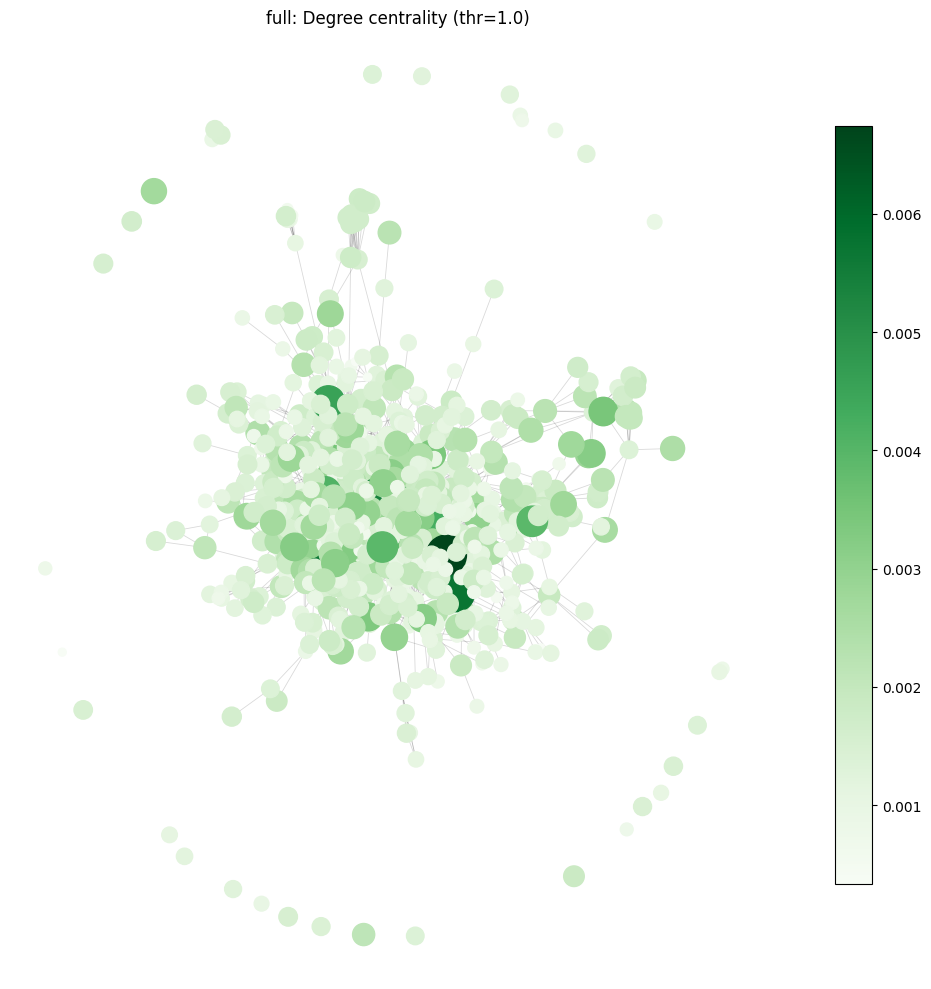

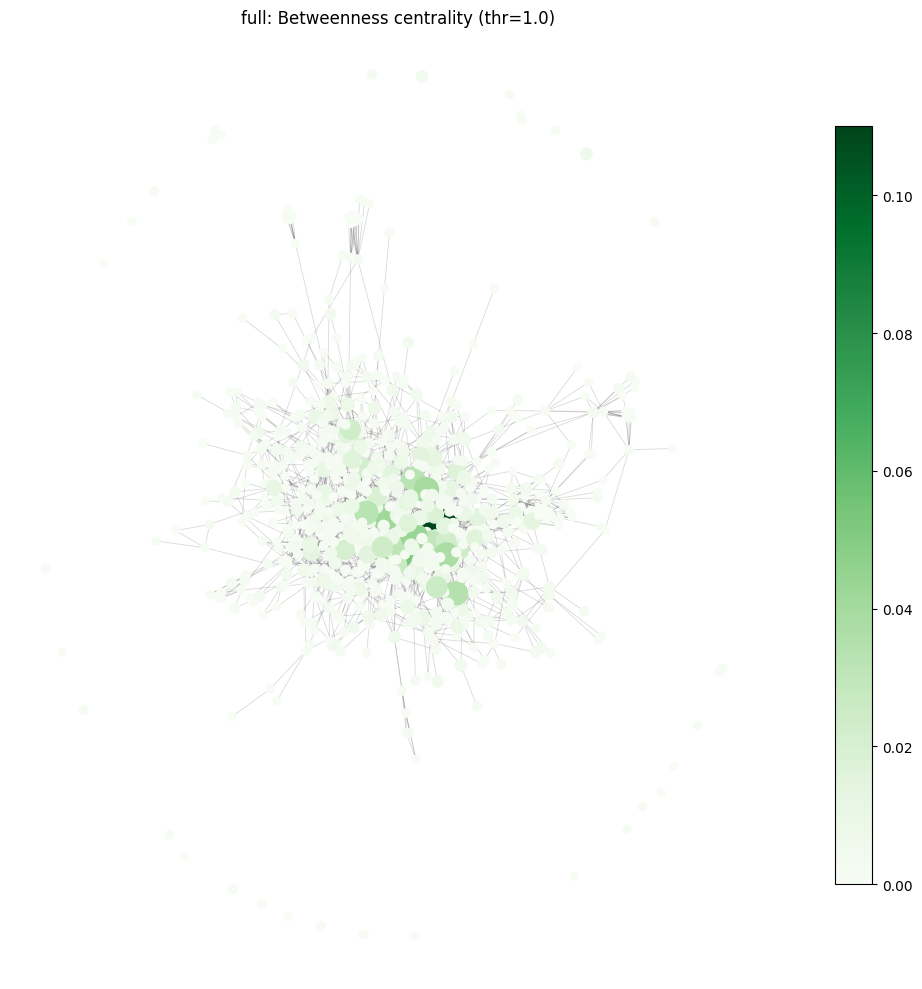

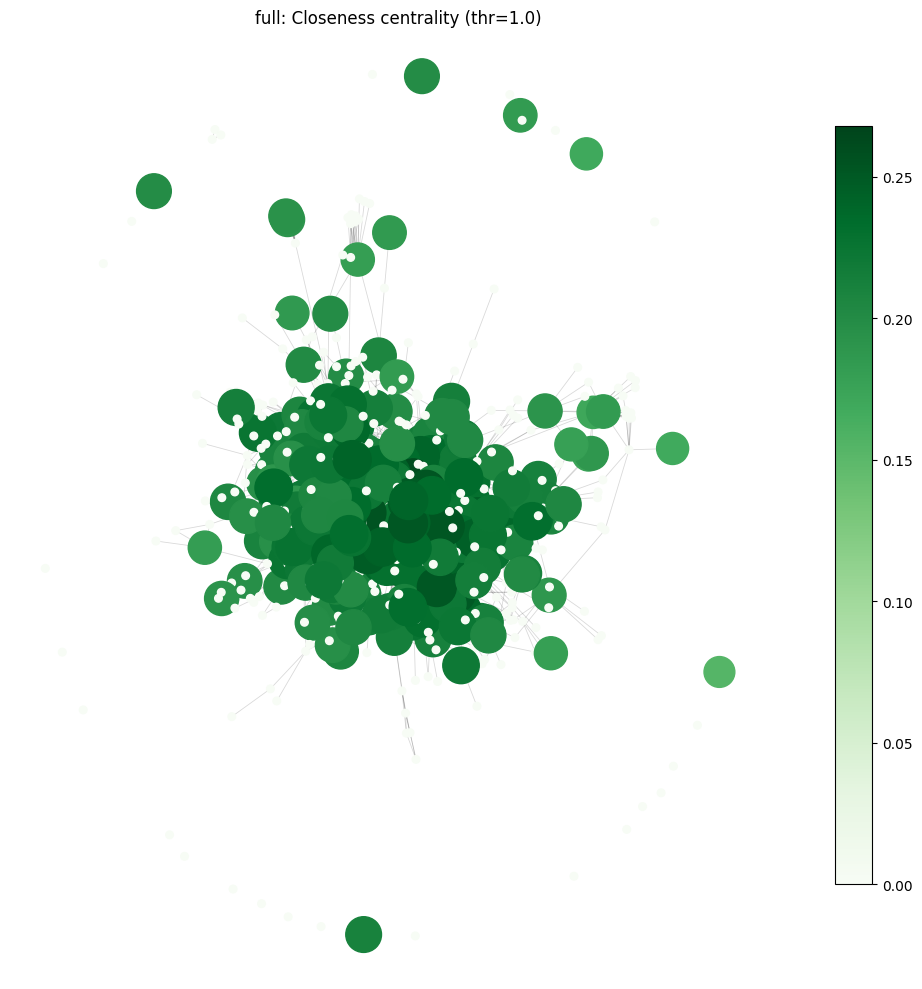

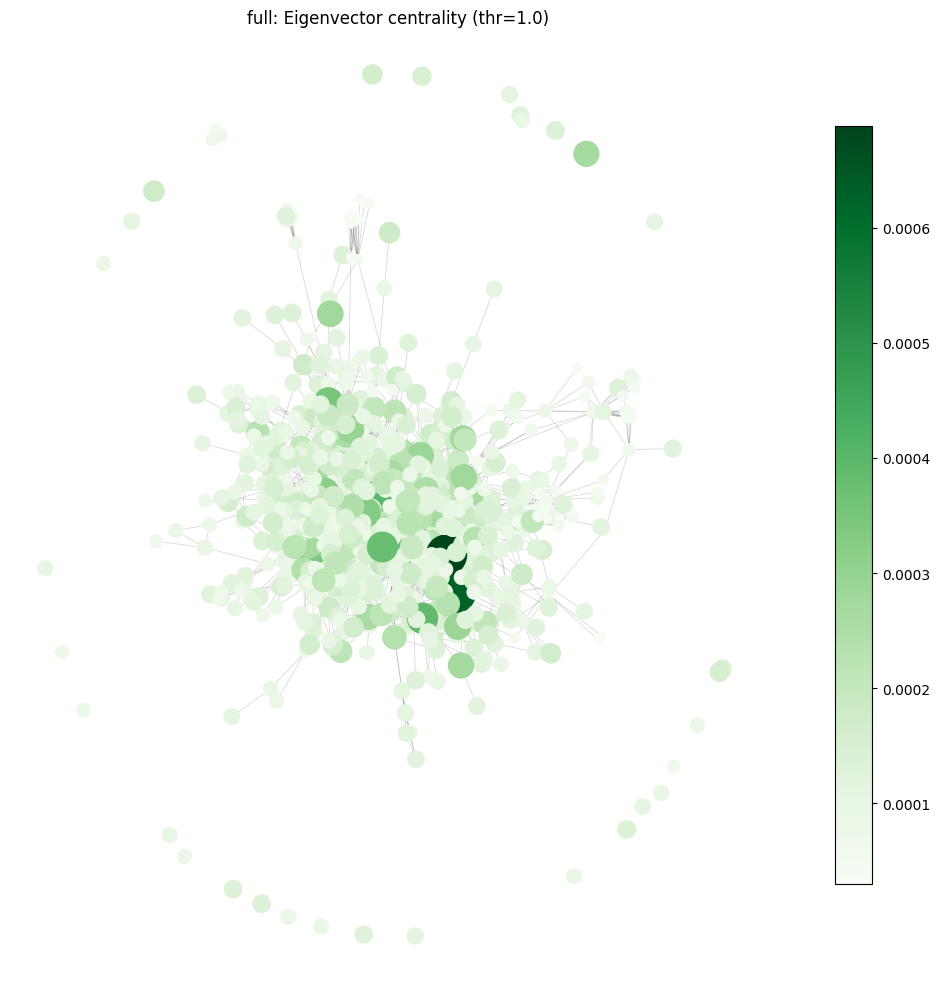

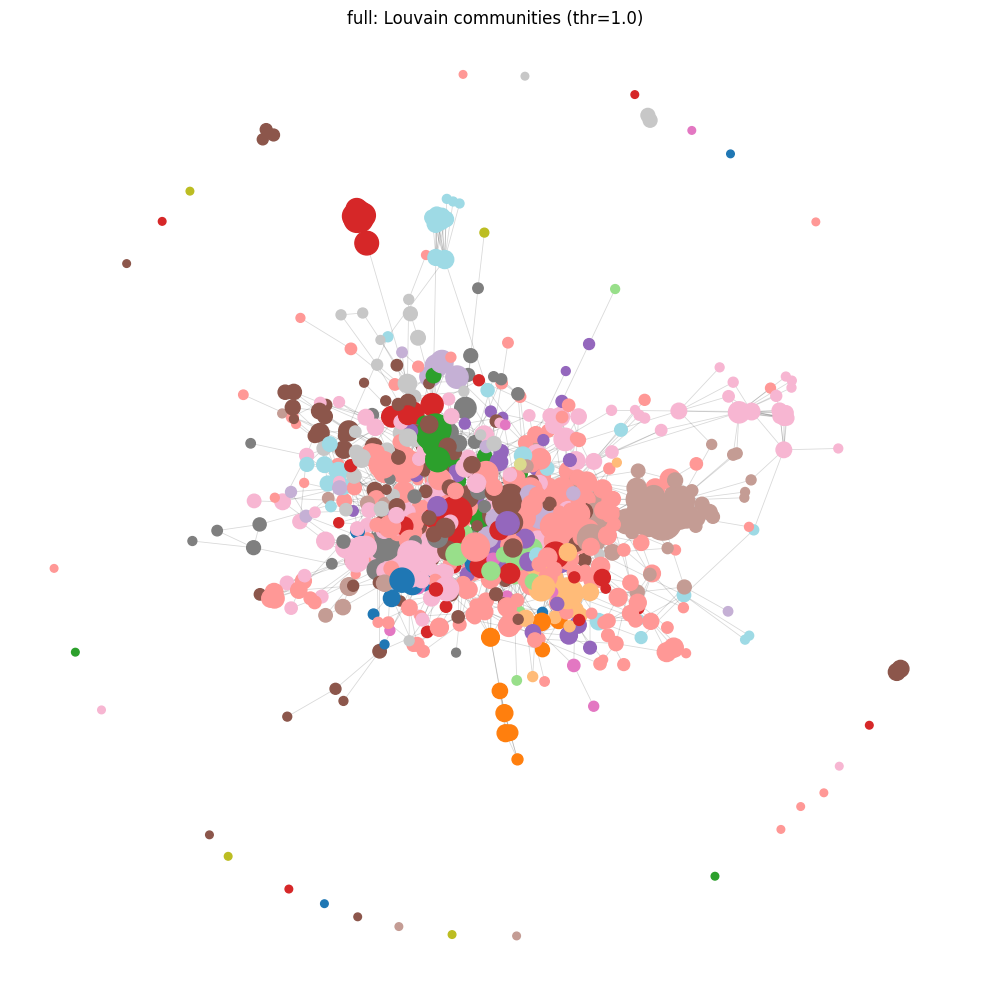

Done. Artifacts saved to: /content/drive/MyDrive/collab_results_bananika/full_20260202_215140
Total pipeline time: 640.56 s
Saved authors_summary.csv


In [ ]:
ts = time.strftime("%Y%m%d_%H%M%S")
out_full = os.path.join(OUTPUT_BASE, f"full_{ts}")

G_all = build_weighted_graph_paperstyle(df, authors_col="authors")
print("[Full graph] nodes:", G_all.number_of_nodes(), "edges:", G_all.number_of_edges())

cent_all, part_all, mod_all = run_full_pipeline(G_all, out_full, label="full")

authors_summary = pd.DataFrame({
    "author": list(G_all.nodes()),
    "papers": [G_all.nodes[n].get("papers", 0) for n in G_all.nodes()],
    "lead_papers": [G_all.nodes[n].get("lead_papers", 0) for n in G_all.nodes()],
    "community": [part_all.get(n, -1) for n in G_all.nodes()],
})
authors_summary.to_csv(os.path.join(out_full, "authors_summary.csv"), index=False)
print("Saved authors_summary.csv")